# Оптимизация нейронных сетей. Метод обратного распространения ошибки (ноутбук)

> Узнаем как устроена оптимизация нейронных сетей. Оптимизация в `PyTorch`.

## План ноутбука

1. Высокоуровневое API для обучение нейросетей в `PyTorch`
2. Обучение первой нейросети в `PyTorch`

## Высокоуровневое API для обучение нейросетей в `PyTorch`

In [ ]:
import torch
import torch.nn as nn

### Создание объекта нейросети

In [ ]:
input_features_dim = 700
hidden_dim1 = 500
hidden_dim2 = 200
output_logits_dim = 10
net = nn.Sequential(
    nn.Linear(input_features_dim, hidden_dim1),
    nn.ReLU(inplace=True),
    nn.Linear(hidden_dim1, hidden_dim2),
    nn.ReLU(inplace=True),
    nn.Linear(hidden_dim2, output_logits_dim)
)

In [ ]:
net

Sequential(
  (0): Linear(in_features=700, out_features=500, bias=True)
  (1): ReLU(inplace=True)
  (2): Linear(in_features=500, out_features=200, bias=True)
  (3): ReLU(inplace=True)
  (4): Linear(in_features=200, out_features=10, bias=True)
)

In [ ]:
net[2].weight.dtype

torch.float32

In [ ]:
batch_size = 4
input = torch.randn((batch_size, input_features_dim))

In [ ]:
net(input)

tensor([[-0.0246, -0.0272, -0.0280,  0.0838, -0.0739, -0.1706,  0.0890,  0.1039,
         -0.0462,  0.0635],
        [ 0.0762, -0.0959, -0.0670,  0.0028, -0.0079, -0.1194, -0.0083,  0.1748,
         -0.0900,  0.0498],
        [ 0.0107, -0.0815,  0.1230,  0.1489, -0.0128, -0.0725,  0.0808,  0.1350,
         -0.0248, -0.0245],
        [-0.0371,  0.0063, -0.0151,  0.0989,  0.1124, -0.0999, -0.0400,  0.0873,
         -0.1472,  0.0529]], grad_fn=<AddmmBackward0>)

In [ ]:
from collections import OrderedDict

net = nn.Sequential(
    OrderedDict(
        [
            ('linear1', nn.Linear(input_features_dim, hidden_dim1)),
            ('relu1', nn.ReLU(inplace=True)),
            ('linear2', nn.Linear(hidden_dim1, hidden_dim2)),
            ('relu2', nn.ReLU(inplace=True)),
            ('linear3', nn.Linear(hidden_dim2, output_logits_dim))
        ]
    )
)

In [ ]:
net

Sequential(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (relu1): ReLU(inplace=True)
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (relu2): ReLU(inplace=True)
  (linear3): Linear(in_features=200, out_features=10, bias=True)
)

In [ ]:
net.linear2, net[2]

(Linear(in_features=500, out_features=200, bias=True),
 Linear(in_features=500, out_features=200, bias=True))

In [ ]:
net(input).shape  # batch_size x output_logits_dim

torch.Size([4, 10])

In [ ]:
class CustomTaskNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(input_features_dim, hidden_dim1)
        self.linear2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.linear3 = nn.Linear(hidden_dim2, output_logits_dim)

        self.activation = nn.ReLU(inplace=True)

    def forward(self, x):
        if self.training:
            print('training')
        x = self.activation(self.linear1(x))
        x = self.activation(self.linear2(x))
        x = self.linear3(x)

        return x

In [ ]:
net = CustomTaskNetwork()

net.train()
net(input).shape

training


torch.Size([4, 10])

In [ ]:
net.eval()
net(input).shape

torch.Size([4, 10])

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
net.to(device)

cuda:0


CustomTaskNetwork(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (linear3): Linear(in_features=200, out_features=10, bias=True)
  (activation): ReLU(inplace=True)
)

In [ ]:
net.parameters()

<generator object Module.parameters at 0x78d7e88bcc10>

In [ ]:
next(iter(net.parameters()))

Parameter containing:
tensor([[ 0.0327, -0.0170,  0.0035,  ..., -0.0366,  0.0256, -0.0236],
        [ 0.0099,  0.0158, -0.0234,  ...,  0.0181,  0.0374, -0.0118],
        [-0.0198, -0.0239, -0.0045,  ..., -0.0243, -0.0317, -0.0038],
        ...,
        [ 0.0036, -0.0161, -0.0139,  ..., -0.0220,  0.0131, -0.0288],
        [-0.0202,  0.0272, -0.0135,  ..., -0.0228, -0.0283,  0.0191],
        [ 0.0195,  0.0210, -0.0060,  ...,  0.0143, -0.0165, -0.0134]],
       device='cuda:0', requires_grad=True)

In [ ]:
net.linear1.weight

Parameter containing:
tensor([[ 0.0327, -0.0170,  0.0035,  ..., -0.0366,  0.0256, -0.0236],
        [ 0.0099,  0.0158, -0.0234,  ...,  0.0181,  0.0374, -0.0118],
        [-0.0198, -0.0239, -0.0045,  ..., -0.0243, -0.0317, -0.0038],
        ...,
        [ 0.0036, -0.0161, -0.0139,  ..., -0.0220,  0.0131, -0.0288],
        [-0.0202,  0.0272, -0.0135,  ..., -0.0228, -0.0283,  0.0191],
        [ 0.0195,  0.0210, -0.0060,  ...,  0.0143, -0.0165, -0.0134]],
       device='cuda:0', requires_grad=True)

In [ ]:
net.state_dict()

In [ ]:
torch.save(net.state_dict(), "weights.pth")

In [ ]:
weights = torch.load("weights.pth", weights_only=True)
net.to("cuda:0")
net.load_state_dict(weights)
net.state_dict()

Если мы хотим проинициализировать сетку какими-то весами из словаря, то важно чтобы названия и размеры параметров в передаваемом словаре совпадали с названиями и размерами параметров сетки

In [ ]:
net.linear1.weight.shape

torch.Size([500, 700])

In [ ]:
net.load_state_dict({'linear1.weight': torch.rand((hidden_dim1, input_features_dim))})

### Оптимизаторы

In [ ]:
import torch.optim as optim

In [ ]:
optim.SGD, optim.Adam, optim.AdamW

(torch.optim.sgd.SGD, torch.optim.adam.Adam, torch.optim.adamw.AdamW)

In [ ]:
optimizer = optim.SGD(net.parameters(), lr=3e-4)

In [ ]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [ ]:
optimizer = optim.SGD(
    [
        {'params': net.linear1.parameters(), 'lr': 3e-4},
        {'params': net.linear2.parameters(), 'lr': 1e-3}
    ],
    lr=1e-2,
    momentum=0.9
)

In [ ]:
optimizer.step()

In [ ]:
optimizer.zero_grad()

### Функции потерь

In [ ]:
nn.L1Loss, nn.MSELoss, nn.CrossEntropyLoss

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
batch_size = 4
input = torch.randn((batch_size, input_features_dim))
target = torch.randn(batch_size, output_logits_dim)
net.train()
net.to('cpu')
logits = net(input)

loss = loss_fn(logits, target)

print(loss)

loss.backward()

training
tensor(-1.2226, grad_fn=<DivBackward1>)


In [ ]:
net.linear1.weight.grad

tensor([[-0.0157,  0.0314, -0.0014,  ..., -0.0056, -0.0042, -0.0059],
        [-0.0083,  0.0077,  0.0209,  ..., -0.0244,  0.0157, -0.0113],
        [ 0.0150,  0.0110, -0.0038,  ..., -0.0072, -0.0226, -0.0172],
        ...,
        [ 0.0172, -0.0005, -0.0098,  ...,  0.0041, -0.0216, -0.0079],
        [ 0.0177, -0.0017, -0.0090,  ...,  0.0034, -0.0209, -0.0081],
        [-0.0149,  0.0136, -0.0042,  ...,  0.0055,  0.0035,  0.0065]])

### Датасеты и даталоадеры

In [ ]:
from torchvision.datasets import MNIST
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, Compose, Lambda

dataset = MNIST(root="./mnist_example", train=True,
                transform=Compose([ToTensor(),
                                   Lambda(lambda x: torch.flatten(x))]),
                download=True)

In [ ]:
len(dataset)

60000

In [ ]:
# dataset[0]

In [ ]:
dataset[0][0].shape, dataset[0][1]

(torch.Size([784]), 5)

In [ ]:
28 * 28

784

In [ ]:
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=False)

In [ ]:
next(iter(dataloader))

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([4, 2, 8, 5])]

## Создадим свой датасет

In [ ]:
!kaggle datasets download balraj98/facades-dataset
!unzip -q facades-dataset.zip -d facades

Dataset URL: https://www.kaggle.com/datasets/balraj98/facades-dataset
License(s): other
 75% 25.0M/33.5M [00:00<00:00, 48.3MB/s]
100% 33.5M/33.5M [00:00<00:00, 61.3MB/s]


In [ ]:
!ls facades

metadata.csv  testA  testB  trainA  trainB


In [ ]:
import pandas as pd

df = pd.read_csv('facades/metadata.csv')
df

,image_id,domain,split,image_path
0,1,B (Facade Segmentation),test,testB/1.jpg
1,1,B (Facade Segmentation),test,testB/1.jpg
2,10,B (Facade Segmentation),test,testB/10.jpg
3,10,B (Facade Segmentation),test,testB/10.jpg
4,100,B (Facade Segmentation),test,testB/100.jpg
...,...,...,...,...
1007,99,B (Facade Segmentation),test,testB/99.jpg
1008,99_A,A (Facade Photo),train,trainA/99_A.jpg
1009,99_B,B (Facade Segmentation),train,trainB/99_B.jpg
1010,9_A,A (Facade Photo),train,trainA/9_A.jpg


In [ ]:
!ls facades/testA | head -n 10

100.jpg
101.jpg
102.jpg
103.jpg
104.jpg
105.jpg
106.jpg
10.jpg
11.jpg
12.jpg


In [ ]:
# !pip install jpeg4py

In [ ]:
import jpeg4py
import cv2

def fast_imread(image_path):
    image_path = str(image_path)
    if image_path.endswith(".jpg") or image_path.endswith(".jpeg"):
        try:
            return jpeg4py.JPEG(image_path).decode()
        except:
            pass

    return cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

array([[[ 98,  88,  76],
        [ 87,  77,  65],
        [ 80,  70,  58],
        ...,
        [  6,   3,  20],
        [  6,   2,  25],
        [  6,   2,  29]],

       [[102,  92,  80],
        [ 92,  82,  70],
        [ 84,  74,  62],
        ...,
        [  6,   3,  20],
        [  6,   2,  25],
        [  6,   2,  29]],

       [[109,  99,  87],
        [102,  92,  80],
        [ 91,  81,  69],
        ...,
        [  6,   3,  20],
        [  6,   2,  25],
        [  6,   2,  29]],

       ...,

       [[  9,   1,   0],
        [ 33,  25,  22],
        [ 56,  48,  45],
        ...,
        [  6,  10,  22],
        [  0,   5,  21],
        [  0,   5,  24]],

       [[  7,   0,   0],
        [ 25,  17,  14],
        [ 44,  37,  31],
        ...,
        [  4,   8,  20],
        [  0,   4,  18],
        [  0,   6,  22]],

       [[ 13,   5,   2],
        [ 25,  17,  14],
        [ 38,  31,  25],
        ...,
        [  3,   7,  19],
        [  0,   3,  17],
        [  0,   6,  22]]], dtype=uint8)
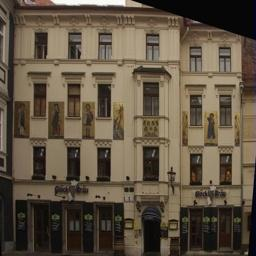

In [ ]:
fast_imread('facades/testA/100.jpg')

In [ ]:
import os
from PIL import Image
import torchvision.transforms as T


class FacadesDataset(Dataset):
    def __init__(self, dir_name, split='train', img_transforms=None):
        self.dir_name = dir_name
        self.split = split
        self.transforms = img_transforms
        if self.transforms is None:
            self.transforms = T.ToTensor()

        meta = pd.read_csv(os.path.join(self.dir_name, 'metadata.csv'))
        self.meta = meta[meta.split == split]

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, index):
        item = self.meta.iloc[index]
        img_path = os.path.join(self.dir_name, item['image_path'])
        label = item['domain']
        # img = Image.open(img_path)  # there several ways to speed up Image.open()
        img = fast_imread(img_path)
        img = self.transforms(img)
        return img, label, img_path

In [ ]:
dataset = FacadesDataset(dir_name='facades', split='train')

In [ ]:
dataset[10][0].shape, dataset[10][1], dataset[10][2]

(torch.Size([3, 256, 256]), 'A (Facade Photo)', 'facades/trainA/105_A.jpg')

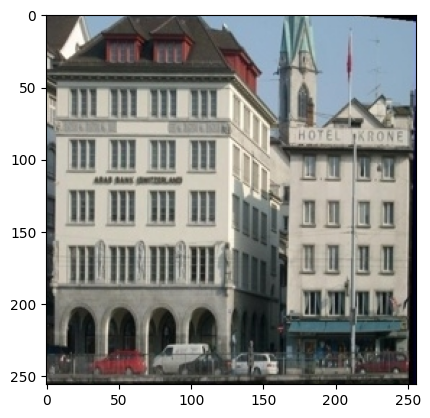

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(dataset[10][0].permute(1, 2, 0));

### Общая структура обучения модели

Модель

In [ ]:
input_features_dim = 28 * 28
output_logits_dim = 10
class CustomTaskNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(input_features_dim, hidden_dim1)
        self.linear2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.linear3 = nn.Linear(hidden_dim2, output_logits_dim)

        self.activation = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.activation(self.linear1(x))
        x = self.activation(self.linear2(x))
        x = self.linear3(x)

        return x

model = CustomTaskNetwork()

Оптимизатор

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=1e-2)

Функция потерь

In [ ]:
loss_fn = nn.CrossEntropyLoss()

Данные

In [ ]:
dataset = MNIST(root="./mnist_example", train=True,
                transform=Compose([ToTensor(),
                                   Lambda(lambda x: torch.flatten(x))]))

batch_size = 128
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

Fix seed

In [ ]:
import os
import torch
import random
import numpy as np


def seed_everything(seed, deterministic=False):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = deterministic  # mostly always False
    torch.backends.cudnn.benchmark = True  # if input sizes do not vary - set to True increase speed

Обучение

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

Training:   0%|          | 0/468 [00:00<?, ?it/s]

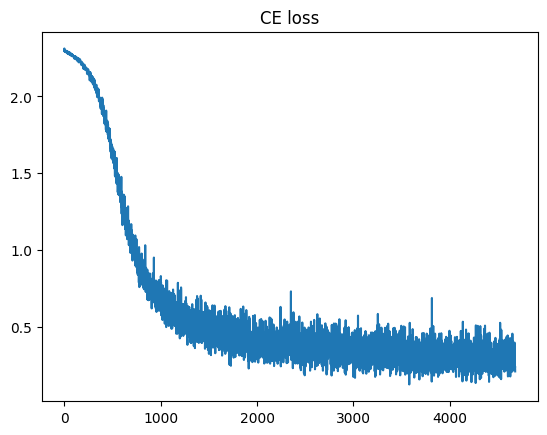

In [ ]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

seed_everything(3407)  # https://arxiv.org/abs/2109.08203
model.train()
model.to(device)
loss_history = []
for epoch in range(10):
    for x, y in tqdm(dataloader, desc="Training"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = loss_fn(logits, y)

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

plt.plot(loss_history)
plt.title("CE loss")
plt.show()

Сохранение обученной модели

In [ ]:
torch.save(model.state_dict(), "my_model.pth")

Применение обученной модели для получения предсказания

In [ ]:
model.eval()

with torch.inference_mode():
    print(torch.argmax(model(dataset[0][0].to(device))))

tensor(5, device='cuda:0')


In [ ]:
dataset = MNIST("./mnist_example")
dataset[0][0]

## Wandb

In [ ]:
from dataclasses import dataclass


@dataclass
class SomeConfig:
    wandb_project: str = 'project_name'
    device: str = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    save_path: str = 'weights'
    seed: int = 3407
    model_save_name: str = 'ft'

    num_workers: int = 8
    num_epochs: int = 10
    save_epochs: int = 4
    validate_epochs: int = 2

    optim: str = 'AdamW'
    batch_size: int = 128
    learning_rate: float = 1e-4
    beta1: float = 0.9
    beta2: float = 0.999

In [ ]:
# wandb.log{'train/accuracy': 0.15}

In [ ]:
from datetime import datetime
# import numpy as np
import wandb


class WanDBWriter:
    def __init__(self, config):
        self.writer = None
        self.selected_module = ""

        wandb.login()

        if not hasattr(config, 'wandb_project'):
            raise ValueError("please specify project name for wandb")

        wandb.init(
            project=getattr(config, 'wandb_project'),
            config=config
        )
        self.wandb = wandb

        self.step = 0
        self.mode = ""
        self.timer = datetime.now()

    def set_step(self, step, mode="train"):
        self.mode = mode
        self.step = step
        if step == 0:
            self.timer = datetime.now()
        else:
            duration = datetime.now() - self.timer
            self.add_scalar("steps_per_sec", 1 / duration.total_seconds())
            self.timer = datetime.now()

    def scalar_name(self, scalar_name):
        return f"{self.mode}/{scalar_name}"

    def watch_model(self, model, criterion=None):
        self.wandb.watch(model)

    def add_scalar(self, scalar_name, scalar):
        self.wandb.log({
            self.scalar_name(scalar_name): scalar,
        }, step=self.step)

    def add_scalars(self, tag, scalars):
        self.wandb.log({
            **{f"{scalar_name}_{tag}_{self.mode}": scalar for scalar_name, scalar in scalars.items()}
        }, step=self.step)

    def add_image(self, scalar_name, image):
        self.wandb.log({
            self.scalar_name(scalar_name): self.wandb.Image(image)
        }, step=self.step)

    def add_audio(self, scalar_name, audio, sample_rate=None):
        # audio = audio.detach().cpu().numpy().T
        audio = audio.T
        self.wandb.log({
            self.scalar_name(scalar_name): self.wandb.Audio(audio, sample_rate=sample_rate)
        }, step=self.step)

    def add_text(self, scalar_name, text):
        self.wandb.log({
            self.scalar_name(scalar_name): self.wandb.Html(text)
        }, step=self.step)

    # def add_histogram(self, scalar_name, hist, bins=None):
    #     hist = hist.detach().cpu().numpy()
    #     np_hist = np.histogram(hist, bins=bins)
    #     if np_hist[0].shape[0] > 512:
    #         np_hist = np.histogram(hist, bins=512)
    #
    #     hist = self.wandb.Histogram(
    #         np_histogram=np_hist
    #     )
    #
    #     self.wandb.log({
    #         self.scalar_name(scalar_name): hist
    #     }, step=self.step)

    def add_images(self, scalar_name, images):
        raise NotImplementedError()

    def add_pr_curve(self, scalar_name, scalar):
        raise NotImplementedError()

    def add_embedding(self, scalar_name, scalar):
        raise NotImplementedError()

In [ ]:
config = SomeConfig()
seed_everything(config.seed, deterministic=False)
logger = WanDBWriter(config)
current_step = 0

tqdm_bar = tqdm(total=config.num_epochs * len(dataloader) - current_step)
for epoch in range(config.num_epochs):
    ....
    for data in dataloader:
        current_step += 1
        tqdm_bar.update(1)
        logger.set_step(current_step, 'train')
        ....

        accuracy = 0.67
        logger.add_scalar('loss', loss.item())
        logger.add_scalar('accuracy', accuracy)

    mean_loss = 0.136
    accuracy_epoch = 0.73
    logger.add_scalar('mean_loss', mean_loss)
    logger.add_scalar('accuracy_epoch', accuracy_epoch)

    if epoch % config.validate_epochs == config.validate_epochs - 1 or epoch == config.num_epochs - 1:
        ....
        logger.set_step(current_step, 'test')
        logger.add_scalar('mean_loss', mean_loss)
        logger.add_scalar('accuracy_epoch', accuracy_epoch)